<a href="https://colab.research.google.com/github/sumitsingh0065/Python_DSA/blob/main/Copy_of_Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Creating a messy dataset
data = {
    'Transaction_ID': range(101, 111),
    'Customer_Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace', 'Heidi', 'Ivan', 'Judy'],
    'Customer_Age': [25, 30, np.nan, 45, 22, np.nan, 38, 50, 29, 33], # Missing values
    'Membership_Type': ['Gold', 'Silver', 'Gold', 'Bronze', 'Silver', 'Bronze', 'Gold', 'Silver', 'Gold', 'Bronze'],
    'Price': ['$1,200', '$850', '$1,100', '$400', '$900', '$350', '$1,500', '$700', '$1,250', '$500'] # String with symbols
}

df_raw = pd.DataFrame(data)
df_raw.to_csv('retail_raw_data.csv', index=False)
print("File 'retail_raw_data.csv' created successfully!")

File 'retail_raw_data.csv' created successfully!


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Transaction_ID   10 non-null     int64  
 1   Customer_Name    10 non-null     object 
 2   Customer_Age     8 non-null      float64
 3   Membership_Type  10 non-null     object 
 4   Price            10 non-null     object 
dtypes: float64(1), int64(1), object(3)
memory usage: 532.0+ bytes


In [ ]:
df_raw.describe()

,Transaction_ID,Customer_Age
count,10.00000,8.000000
mean,105.50000,34.000000
std,3.02765,9.710083
min,101.00000,22.000000
25%,103.25000,28.000000
50%,105.50000,31.500000
75%,107.75000,39.750000
max,110.00000,50.000000


**Goal: Identify data types and "null" gaps.**

In [ ]:
df_raw.isnull().sum()

,0
Transaction_ID,0
Customer_Name,0
Customer_Age,2
Membership_Type,0
Price,0


# Command: df.isnull().sum()

Result: It returns the count of missing (NaN) values for each column.
To exactly identify the "holes" in their dataset and determine which columns need imputation (like the Customer_Age column in our case study).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('retail_raw_data.csv')

# Audit
print(df.info())
print("\nMissing values:\n", df.isnull())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Transaction_ID   10 non-null     int64  
 1   Customer_Name    10 non-null     object 
 2   Customer_Age     8 non-null      float64
 3   Membership_Type  10 non-null     object 
 4   Price            10 non-null     object 
dtypes: float64(1), int64(1), object(3)
memory usage: 532.0+ bytes
None

Missing values:
    Transaction_ID  Customer_Name  Customer_Age  Membership_Type  Price
0           False          False         False            False  False
1           False          False         False            False  False
2           False          False          True            False  False
3           False          False         False            False  False
4           False          False         False            False  False
5           False          False          True            Fal

In [ ]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 Transaction_ID     0
Customer_Name      0
Customer_Age       2
Membership_Type    0
Price              0
dtype: int64


In [ ]:
# 1. Create a mask for rows with ANY null values
null_rows_mask = df.isnull().any(axis=1)

# 2. Filter the dataframe using that mask to see the IDs
null_ids = df.loc[null_rows_mask, 'Transaction_ID']

print("IDs of rows with missing data:")
print(null_ids)

IDs of rows with missing data:
2    103
5    106
Name: Transaction_ID, dtype: int64


# Fill the missing values

In [ ]:
# 1. Fill missing Age with Median
print(df)
df['Customer_Age'] = df['Customer_Age'].fillna(df['Customer_Age'].median())

df

   Transaction_ID Customer_Name  Customer_Age Membership_Type   Price
0             101         Alice          25.0            Gold  $1,200
1             102           Bob          30.0          Silver    $850
2             103       Charlie           NaN            Gold  $1,100
3             104         David          45.0          Bronze    $400
4             105           Eve          22.0          Silver    $900
5             106         Frank           NaN          Bronze    $350
6             107         Grace          38.0            Gold  $1,500
7             108         Heidi          50.0          Silver    $700
8             109          Ivan          29.0            Gold  $1,250
9             110          Judy          33.0          Bronze    $500


,Transaction_ID,Customer_Name,Customer_Age,Membership_Type,Price
0,101,Alice,25.0,Gold,"$1,200"
1,102,Bob,30.0,Silver,$850
2,103,Charlie,31.5,Gold,"$1,100"
3,104,David,45.0,Bronze,$400
4,105,Eve,22.0,Silver,$900
5,106,Frank,31.5,Bronze,$350
6,107,Grace,38.0,Gold,"$1,500"
7,108,Heidi,50.0,Silver,$700
8,109,Ivan,29.0,Gold,"$1,250"
9,110,Judy,33.0,Bronze,$500


# Convert text categories into numerical "flags" for models.

In [ ]:
# One-Hot Encoding for Membership_Type
df_encoded = pd.get_dummies(df, columns=['Membership_Type'], prefix='Member')
print(df_encoded.head())

   Transaction_ID Customer_Name  Customer_Age   Price  Member_Bronze  \
0             101         Alice          25.0  $1,200          False   
1             102           Bob          30.0    $850          False   
2             103       Charlie          31.5  $1,100          False   
3             104         David          45.0    $400           True   
4             105           Eve          22.0    $900          False   

   Member_Gold  Member_Silver  
0         True          False  
1        False           True  
2         True          False  
3        False          False  
4        False           True  


In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Transaction_ID  10 non-null     int64  
 1   Customer_Name   10 non-null     object 
 2   Customer_Age    10 non-null     float64
 3   Price           10 non-null     object 
 4   Member_Bronze   10 non-null     bool   
 5   Member_Gold     10 non-null     bool   
 6   Member_Silver   10 non-null     bool   
dtypes: bool(3), float64(1), int64(1), object(2)
memory usage: 482.0+ bytes


In [ ]:
# Calculate average spending and age per membership group
# Note: Use original 'df' for readable category names
summary = df.groupby('Membership_Type')[['Price', 'Customer_Age']].mean().reset_index()

print("--- Business Summary ---")
print(summary)

TypeError: agg function failed [how->mean,dtype->object]

In [ ]:
df['Customer_Age'].isnull().sum()

np.int64(0)

**# df.groupby('Column_to_Group_By')['Column_to_Calculate'].Function()**

In [ ]:
# Remove anything that is NOT a digit or a period, then convert to float
df['Price'] = df['Price'].replace(r'[$,]', '', regex=True).astype(float)

# AGGREGATE BOTH: Group by Membership and calculate mean for Price AND Age
# Using double brackets [[...]] returns a DataFrame instead of a Series
summary = df.groupby('Membership_Type')[['Price', 'Customer_Age']].mean()

print("--- Cleaned Summary (Price & Age) ---")
print(summary)

--- Cleaned Summary (Price & Age) ---
                       Price  Customer_Age
Membership_Type                           
Bronze            416.666667        36.500
Gold             1262.500000        30.875
Silver            816.666667        34.000


/tmp/ipython-input-337972540.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='Membership_Type', y='Price', palette='magma')


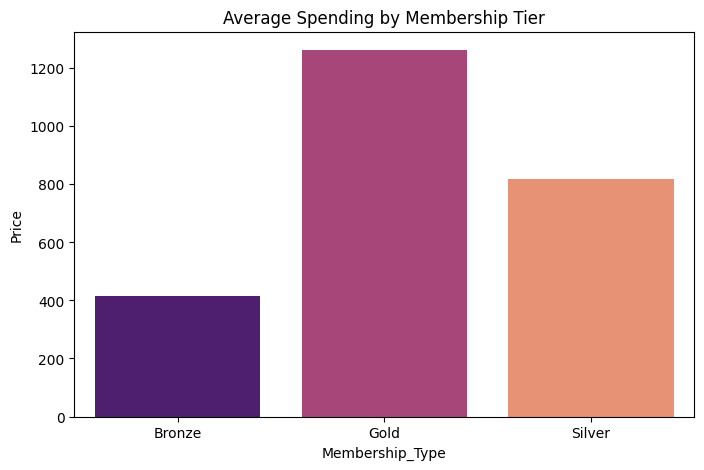

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=summary, x='Membership_Type', y='Price', palette='magma')
plt.title('Average Spending by Membership Tier')
plt.show()

In [ ]:
# 1. Count how many customers are in each category
membership_counts = df['Membership_Type'].value_counts()

print(membership_counts)

Membership_Type
Gold      4
Silver    3
Bronze    3
Name: count, dtype: int64


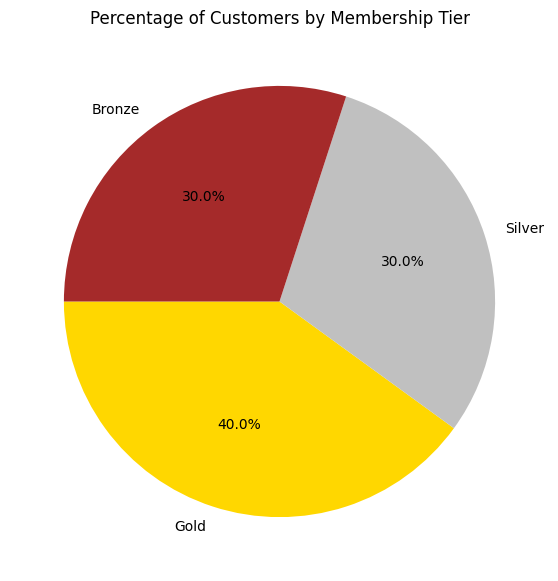

In [ ]:
# 2. Plot the Pie Chart
plt.figure(figsize=(7, 7))
plt.pie(membership_counts,
        labels=membership_counts.index,
        autopct='%1.1f%%',      # This adds the percentage labels automatically
        startangle=180,
        colors=['gold', 'silver', 'brown'])

plt.title('Percentage of Customers by Membership Tier')
plt.show()